# **Импорт библиотек, загрузка начальных параметров**

In [1]:
import os
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from tqdm import tqdm
from torchvision import transforms

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
short_dataset = '/content/drive/MyDrive/Celebs_short_dataset'
aligned_dataset = '/content/drive/MyDrive/aligned_faces_2'
mapping_csv = '/content/drive/MyDrive/Celebs_subsample_2.csv'

In [5]:
BATCH_SIZE = 128
num_workers = 4

In [6]:
# так как у меня размер картинок 128, то придется или ресайзить их в цикле, что обнулит шансы на
# вероятное использование ГПУ, или нужно пересохранить их в формате тензора с сохранением имени (но с другим
# расширением, конечно). Название файла сохраняется, так что identity все еще можно будет определить.

In [ ]:
src = aligned_dataset
dst = "/content/drive/MyDrive/aligned_faces_resized"
os.makedirs(dst, exist_ok=True)

transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

for f in os.listdir(src):
    img = Image.open(os.path.join(src, f)).convert("RGB")
    tensor = transform(img)
    torch.save(tensor, os.path.join(dst, f.replace(".jpg", ".pt")))

In [8]:
aligned_dataset = '/content/drive/MyDrive/aligned_faces_resized'

In [21]:
df = pd.read_csv(mapping_csv)
key_columns = ['image_id', 'identity']
df = df[key_columns]
# перенумерация identity
unique_ids = sorted(df['identity'].unique())
id2new = {old: new for new, old in enumerate(unique_ids)}
df['identity'] = df['identity'].map(id2new)
# проверяем распределение по персонам
person_count = df['identity'].value_counts()
print(f"Всего уникальных персон: {len(person_count)}")
print(f"Минимальное количество изображений на персону: {person_count.min()}")
print(f"Максимальное количество изображений на персону: {person_count.max()}")
if person_count.min() == person_count.max():
    print(f'Все персоны имеют равное количество изображений, {person_count.min()} - это отлично для балансировки!')

Всего уникальных персон: 500
Минимальное количество изображений на персону: 30
Максимальное количество изображений на персону: 30
Все персоны имеют равное количество изображений, 30 - это отлично для балансировки!


# Создание даталоудера и обучение ResNet18

Чтобы сделать обучение эффективным, нужно каждую identity  распределить в определенной пропорции между train, test & validation dataset.

In [23]:
def split_by_identity(df, seed=42):
    np.random.seed(seed)

    train_rows = []
    val_rows = []
    test_rows = []

    for identity, group in df.groupby("identity"):
        # перемешиваем внутри группы
        group = group.sample(frac=1, random_state=seed)
        # 6 train
        train_rows.append(group.iloc[:22])
        # 2 val
        val_rows.append(group.iloc[22:26])
        # 2 test
        test_rows.append(group.iloc[26:30])

    train_df = pd.concat(train_rows).reset_index(drop=True)
    val_df = pd.concat(val_rows).reset_index(drop=True)
    test_df = pd.concat(test_rows).reset_index(drop=True)

    return train_df, val_df, test_df

для обучения модели нужно каждое изображение прогонять через FaceDatasetPT. Данный процесс определяет соответствие тензора изображения и identity, информация о которой есть только в csv.

In [22]:
class FaceDatasetPT(Dataset):
    def __init__(self, root, csv_path):
        self.root = root
        self.mapping = {}

        with open(csv_path, "r") as f:
            reader = csv.DictReader(f)
            for row in reader:
                filename = row["image_id"].replace(".jpg", ".pt")
                label = int(row["identity"])
                self.mapping[filename] = label

        self.files = list(self.mapping.keys())

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]
        label = self.mapping[filename]

        tensor = torch.load(os.path.join(self.root, filename))
        return tensor, label


In [11]:
# создаем трейн, тест и валидационные датасеты, используя функцию пропорционального деления
# сгруппированных по персонажу фотографий

In [24]:
train_img, val_img, test_img = split_by_identity(df)
#
train_img.to_csv("train.csv", index=False)
test_img.to_csv("test.csv", index=False)
val_img.to_csv("val.csv", index=False)
#
train_dataset = FaceDatasetPT(aligned_dataset, "train.csv")
test_dataset = FaceDatasetPT(aligned_dataset, "test.csv")
val_dataset = FaceDatasetPT(aligned_dataset, "val.csv")

In [25]:
# определяем даталоадеры
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)

In [14]:
# считаем количество классов

In [26]:
def count_classes(df):
    return df['identity'].nunique()

In [16]:
num_classes = count_classes(df)
print("Количество классов:", num_classes)

Количество классов: 500


In [17]:
# сами по себе эмбеддинги не являются точным способом определить приналежность картинки к классу.
# необходмо рассчитывать углы между направлением вектора эмбеддинга и весом класса. Добавляем
# margin чтобы сделать близкие вектора более заметными (т.к. косинус маленького числа, т.е. близких векторов будет большой),
# то определение принадлежности к классу будет более четким.

In [34]:
class ArcFace(nn.Module):
    def __init__(self, embedding_size, num_classes, margin=0.2, scale=30):
        super().__init__()
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale # усиливаем чувствительность функции активации

        self.weight = nn.Parameter(torch.randn(num_classes, embedding_size))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        # нормируем эмбеддинги и веса
        embeddings = F.normalize(embeddings)
        W = F.normalize(self.weight)

        # косинус угла
        cosine = torch.matmul(embeddings, W.t())

        # вычисляем угол
        theta = torch.acos(torch.clamp(cosine, -1.0 + 1e-7, 1.0 - 1e-7))

        # добавляем margin
        target_logits = torch.cos(theta + self.margin)

        # создаём логиты
        logits = cosine.clone()
        logits[torch.arange(len(labels)), labels] = target_logits[torch.arange(len(labels)), labels]

        # масштабируем
        logits *= self.scale

        return logits

In [19]:
# функция обучения модели ResNet18 c понижением щага обучения каждые 15 эпох. Тут у меня
# возникла проблема с мощностями (медленно даже за доплату), а так как есть еще хроническая
# проблема начинать поближе к дедлайну, то я рву на себе волосы.

In [35]:
from torch.optim.lr_scheduler import StepLR

def train_arcface(model, train_loader, val_loader, optimizer, criterion, device, epochs, start_epoch=0):
    model.to(device)
    best_val_acc = 0.0

    train_acc_history = []
    val_acc_history = []

    scheduler = StepLR(optimizer, step_size=20, gamma=0.8)

    for epoch in tqdm(range(start_epoch, epochs), desc="Epochs"):
        model.train()
        correct = 0
        total = 0

        train_pbar = tqdm(train_loader, desc=f"Train {epoch+1}/{epochs}", leave=False)
        for imgs, labels in train_pbar:
            imgs = imgs.to(device)
            labels = labels.to(device)

            logits, _ = model(imgs, labels)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # ACCURACY
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            train_pbar.set_postfix({"acc": correct / total})

        train_acc = correct / total
        train_acc_history.append(train_acc)

        # VALIDATION
        model.eval()
        correct = 0
        total = 0

        val_pbar = tqdm(val_loader, desc=f"Val {epoch+1}/{epochs}", leave=False)
        with torch.no_grad():
            for imgs, labels in val_pbar:
                imgs = imgs.to(device)
                labels = labels.to(device)

                logits, _ = model(imgs, labels)

                preds = torch.argmax(logits, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

                val_pbar.set_postfix({"acc": correct / total})

        val_acc = correct / total
        val_acc_history.append(val_acc)

        # сохраняем лучшие веса
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "arcface_best.pth")
            print("✔ Лучшие веса сохранены (по accuracy).")

        # сохраняем код обучения
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
            "train_acc": train_acc,
            "val_acc": val_acc
        }
        torch.save(checkpoint, "checkpoint_arcface.pth")

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        print(f"LR: {optimizer.param_groups[0]['lr']}")

        scheduler.step()

    # в конце выводим график
    plt.figure(figsize=(8,5))
    plt.plot(train_acc_history, label="Train Accuracy")
    plt.plot(val_acc_history, label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid()
    plt.show()

In [29]:
# импортируем ResNet18 - предобученную

In [36]:
from torchvision.models import resnet18, ResNet18_Weights

class FaceModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, 512)

        self.arcface = ArcFace(embedding_size=512, num_classes=num_classes)

    def forward(self, x, labels=None):
        embeddings = self.backbone(x)
        embeddings = F.normalize(embeddings, dim=1)
        if labels is not None:
            logits = self.arcface(embeddings, labels)
            return logits, embeddings
        return embeddings

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используется устройство:", device)

Используется устройство: cuda


In [38]:
# 1 - использование CE лосса при обучении

In [37]:
model = FaceModel(num_classes=num_classes)
optimizer = torch.optim.AdamW([
    {"params": model.backbone.parameters(), "lr": 1e-4},
    {"params": model.arcface.parameters(), "lr": 1e-3},
])
criterion = nn.CrossEntropyLoss()

Train 1/120:  99%|█████████▉| 85/86 [00:20<00:00,  4.45it/s, acc=0]
                                                                   
Epochs:   1%|          | 1/120 [00:24<48:45, 24.58s/it]

Epoch 1/120 | Train Acc: 0.0000 | Val Acc: 0.0000
LR: 0.0001



Train 2/120:  99%|█████████▉| 85/86 [00:20<00:00,  4.94it/s, acc=0.0201]
                                                                        
Val 2/120:  81%|████████▏ | 13/16 [00:03<00:00,  3.96it/s, acc=0.021] 
                                                                     

✔ Лучшие веса сохранены (по accuracy).


Epochs:   2%|▏         | 2/120 [00:49<48:27, 24.64s/it]

...

Epoch 118/120 | Train Acc: 1.0000 | Val Acc: 0.1930
LR: 3.2768000000000016e-05



Train 119/120:  99%|█████████▉| 85/86 [00:20<00:00,  4.69it/s, acc=1]
                                                                     
Epochs:  99%|█████████▉| 119/120 [49:38<00:25, 25.07s/it]

Epoch 119/120 | Train Acc: 1.0000 | Val Acc: 0.1950
LR: 3.2768000000000016e-05



Train 120/120:  99%|█████████▉| 85/86 [00:20<00:00,  4.18it/s, acc=1]
                                                                     
Epochs: 100%|██████████| 120/120 [50:03<00:00, 25.03s/it]

Epoch 120/120 | Train Acc: 1.0000 | Val Acc: 0.1945
LR: 3.2768000000000016e-05


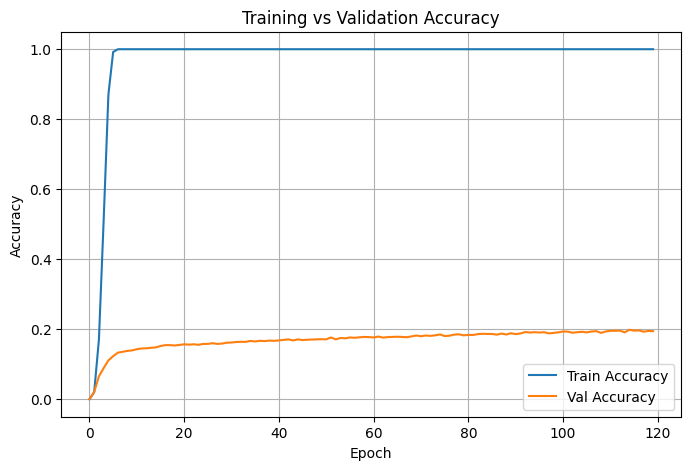

In [39]:
train_arcface(model, train_loader, val_loader, optimizer, criterion, device, epochs=120, start_epoch=0)

In [41]:
checkpoint = torch.load("checkpoint_arcface.pth")

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_epoch = checkpoint["epoch"] + 1
best_val_acc = checkpoint["best_val_acc"]

In [42]:
def get_embedding(model, image_tensor, device="cuda"):
    """
    image_tensor — тензор формата (1, 3, H, W)
    Возвращает эмбеддинг размером (embedding_size)
    """
    image_tensor = image_tensor.to(device)

    # forward без ArcFace head
    _, embedding = model(image_tensor, labels=None)

    return embedding.squeeze().cpu()

In [49]:
def get_embedding(model, tensor, device):
    model.eval()
    with torch.no_grad():
        tensor = tensor.unsqueeze(0).to(device)
        emb = model(tensor)
        emb = F.normalize(emb, dim=1)
    return emb.cpu().numpy()[0]

In [50]:
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [54]:
def recognize_face(model, tensor, gallery, device, threshold=0.5):
    emb = get_embedding(model, tensor, device)

    best_id = None
    best_sim = -1

    for identity, g_emb in gallery.items():
        sim = cosine_sim(emb, g_emb)
        if sim > best_sim:
            best_sim = sim
            best_id = identity

    if best_sim < threshold:
        return None, best_sim

    return best_id, best_sim

In [56]:
import random
from PIL import Image
import os

def random_face_from_df(df, root):
    row = df.sample(1).iloc[0]
    filename = row["image_id"]              # '048685.jpg'
    identity = row["identity"]

    pt_file = filename.replace(".jpg", ".pt")
    tensor = torch.load(os.path.join(root, pt_file))

    return tensor, identity, pt_file

In [58]:
gallery = {}

for identity in df['identity'].unique():
    sample_file = df[df['identity'] == identity].iloc[0]['image_id']
    pt_file = sample_file.replace(".jpg", ".pt")

    tensor = torch.load(os.path.join(aligned_dataset, pt_file))
    emb = get_embedding(model, tensor, device)

    gallery[identity] = emb

In [59]:
img, true_id, filename = random_face_from_df(df, aligned_dataset)

print("Случайный файл:", filename)
print("Истинный ID:", true_id)

identity, score = recognize_face(
    model,
    img,        # теперь это тензор
    gallery,
    device      # transform больше не нужен
)

print("Распознанный ID:", identity)
print("Similarity:", score)

Случайный файл: 066404.pt
Истинный ID: 273
Распознанный ID: 273
Similarity: 0.6498204
